In [1]:
# -*- coding: utf-8 -*-
"""
Created on Mon Jun  8 14:52:00 2020

This is a test file to test the Hypoid class and its methods.

The Hypoid class is defined in the hypoid.py file.

"""
from hypoid.main import Hypoid
from general_utils import dictprint
import numpy as np
import screwCalculus as sc
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

In [2]:

SystemData = {
    'HAND': "Right",
    'taper' : "Standard",
    'hypoidOffset' : 0
}

coneData = {
    'SIGMA' : 90,
    'a' : SystemData['hypoidOffset'],
    'z1' : 9,
    'u' : 3.7,
    'de2': 225,
    'b2' : 38.8,
    'betam1' : 30,
    'rc0' : 75,
    'gearBaseThick' : 15,
    'pinBaseThick' : 8,
}

coneData['z2'] = round(coneData['u']*coneData['z1'])
coneData['u'] = coneData['z2']/coneData['z1']

toothData = {
    'alphaD' : 21,
    'alphaC' : 20,
    'falphalim' : 1,
    'khap' : 1,
    'khfp' : 1.25,
    'xhm1' : 0.45,
    'jen' : 0.1,
    'xsmn' : 0.05,
    'thetaa2' : None,
    'thetaf2' : None
}

H = Hypoid(SystemData, toothData, coneData)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver ma57.

Number of nonzeros in equality constraint Jacobian...:       40
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       27

Total number of variables............................:        9
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        9
                     variables with only upper bounds:        0
Total number of equality constraints.................:        9
Total number of inequality constrai

In [3]:

H.plot('pinion', 'both', whole_gear=True)
H.plot('gear', 'both', whole_gear=True)
dictprint(H.designData)




SystemData
    HAND : Right
    shaft_angle : 90.0
    ratio : 3.6666666666666665
    hypoidOffset : 0
    E : []
    P : []
    G : []
    alpha : []
    taperType : Standard
    transmissionType : Hypoid
    NOMINALDRIVEPRESSUREANGLE : 21.0
    NOMINALCOASTPRESSUREANGLE : 20.0
    NORMALMODULE : 4.922361476095472


GearCommonData
    GenType : Generated
    NTEETH : 33
    SPIRALANGLE : 29.999999999999996
    OUTERCONEDIST : 116.60885029423002
    MEANCONEDIST : 97.20885029423002
    INNERCONEDIST : 77.80885029423003
    MEANNORMALCHORDALTHICKNESS : 5.532460696556178
    MEANADDENDUM : 2.70729881185251
    MEANCHORDALADDENDUM : 2.709503695448437
    FACEWIDTH : 38.8
    FACEANGLE : 77.06464058282644
    BACKANGLE : 74.74488129694222
    FRONTANGLE : 74.74488129694222
    PITCHANGLE : 74.74488129694222
    BASECONEANGLE : 69.8248265545177
    PITCHAPEX : -1.0658141036401503e-14
    FACEAPEX : -1.261597152638341
    ROOTAPEX : -1.0658141036401503e-14
    BASECONEAPEX : -15.9805241452

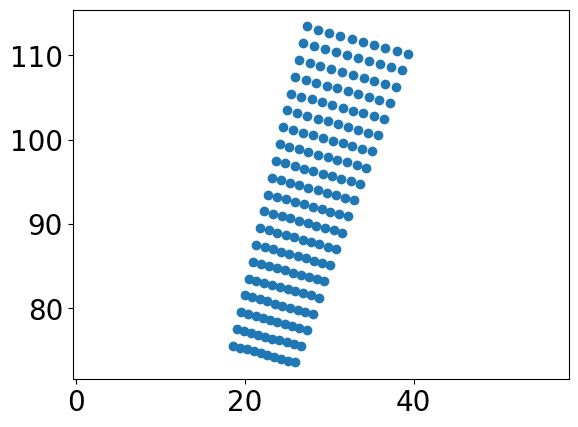

In [4]:
n_face = 10
n_flank = 20
z,R = H.compute_zr_grid('gear', 'convex', n_face, n_flank, active_flank=True)
zR = np.vstack((z.flatten(order='F'), R.flatten(order = 'F'))).T
# %matplotlib qt
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(zR[:,0], zR[:,1])
ax.axis('equal')
plt.show()




In [5]:
print(zR.shape)
print(H.designData['SystemData']['hypoidOffset'])
p, n, triplets_conj, zRconj, psi_P, angular_ease_off, v_pg_p, omega, psi_G =  H.compute_conjugate_points_to_gear('convex', zR, [0,0,0,0], 0)

(200, 2)
0


In [7]:
X = p[0,:].reshape(n_face, n_flank, order='F').T
Y = p[1,:].reshape(n_face, n_flank, order='F').T
Z = p[2,:].reshape(n_face, n_flank, order='F').T

import easy_plot as ep
F = ep.Figure()
S = ep.surface(F,X, Y, Z)
F.show()

In [8]:
%matplotlib qt
H.plot_zr_bounds('gear', 'convex')

In [9]:

z, R = H.compute_zr_grid('pinion', 'concave', 20, 30)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.pcolormesh(z, R, np.zeros_like(z), edgecolors='k', linewidth=0.5)
plt.axis('equal')
H.plot_zr_bounds('pinion', 'concave')

H.zRbounds['pinion']['concave'][0,:]



array([75.57385328, 18.61500117])

In [10]:
points, _, _ = H.samplezR([], [], 'pinion', 'concave')
points_cvx, _, _ = H.samplezR([], [], 'pinion', 'convex')
print(points.shape)

points = np.squeeze(points)
print(points.shape)
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[0,:], points[1,:], points[2,:])
ax.scatter(points_cvx[0,:], points_cvx[1,:], points_cvx[2,:])
# set axis equal
ax.axis('equal')

# set axis labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()



(4, 1, 352)
(4, 352)


In [11]:
H.get_settings_index(machine_settings_names=['RADIALSETTING', 'SPHERICALRADIUS'])

dd = H.get_machine_settings_names()
dictprint(dd)

 RADIALSETTING : 0
 TILTANGLE : 1
 SWIVELANGLE : 2
 BLANKOFFSET : 3
 SLIDINGBASE : 4
 CRADLEANGLE : 5
 INDEXANGLE : 6
 MACHCTRBACK : 7
 ROOTANGLE : 8
 R1 : 9
 R2 : 18
 R3 : 27
 R4 : 36
 R5 : 45
 R6 : 54
 R7 : 63
 SIGMA1 : 10
 SIGMA2 : 19
 SIGMA3 : 28
 SIGMA4 : 37
 SIGMA5 : 46
 SIGMA6 : 55
 SIGMA7 : 64
 ZETA1 : 11
 ZETA2 : 20
 ZETA3 : 29
 ZETA4 : 38
 ZETA5 : 47
 ZETA6 : 56
 ZETA7 : 65
 V1 : 12
 V2 : 21
 V3 : 30
 V4 : 39
 V5 : 48
 V6 : 57
 V7 : 66
 H1 : 13
 H2 : 22
 H3 : 31
 H4 : 40
 H5 : 49
 H6 : 58
 H7 : 67
 Q1 : 14
 Q2 : 23
 Q3 : 32
 Q4 : 41
 Q5 : 50
 Q6 : 59
 Q7 : 68
 RATIOROLL : 15
 C2 : 24
 D6 : 61
 E24 : 42
 F120 : 51
 G720 : 60
 H5040 : 69
 D1 : 16
 D2 : 25
 D3 : 34
 D4 : 43
 D5 : 52
 D7 : 70
 GAMMA1 : 17
 GAMMA2 : 26
 GAMMA3 : 35
 GAMMA4 : 44
 GAMMA5 : 53
 GAMMA6 : 62
 GAMMA7 : 71
 POINTRADIUS : 72
 SPHERICALRADIUS : 73
 EDGERADIUS : 74
 TOPREMRADIUS : 75
 FLANKREMRADIUS : 76
 BLADEANGLE : 77
 TOPREMDEPTH : 78
 FLANKREMDEPTH : 79
 TOPREMANGLE : 80
 FLANKREMANGLE : 81
